In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("iris.csv")

print(df.head())

   150    4  setosa  versicolor  virginica
0  5.1  3.5     1.4         0.2          0
1  4.9  3.0     1.4         0.2          0
2  4.7  3.2     1.3         0.2          0
3  4.6  3.1     1.5         0.2          0
4  5.0  3.6     1.4         0.2          0


In [ ]:

X = df.iloc[:, 0:2].values  
y = df.iloc[:, -1].values   

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print("Accuracy:", knn.score(X_test, y_test))

Accuracy: 0.8


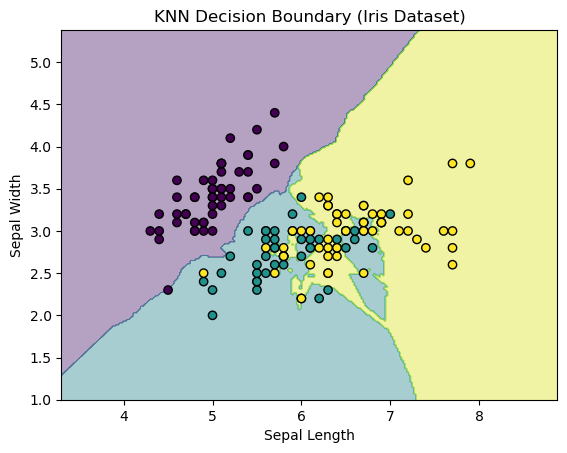

In [ ]:

h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("KNN Decision Boundary (Iris Dataset)")
plt.show()